# LangChain概述

## 什么是LangChain

LangChain是一个用于构建基于语言模型的应用程序的框架。
Lang代表大语言模型LLM（Large Language Model），它是一种基于Transformer架构的神经网络模型，能够理解和生成自然语言。
Chain代表链，它是一种将不同组件连接在一起的方式，以创建一个完整的应用程序。
因此LangChain就是一个⼤模型与外部数据&各种组件连接成链，以此构建AI应⽤程序的框架。

## 为什么要使用LangChain

AI大模型（LLMs）在实际的应用开发中有着以下痛点：
- 不具有上下文记忆能力
- 回答只限制于模型训练的日期
- 不具有工具调用能力
- 对于私有知识库的问题无法进行回答
- 无法做到稳定的输出 比如直接输出一个结构化的json数据

因此我们需要在大模型的基础上新增以下能力：
- 需要具有上下文记忆能力
- 可以检索企业内部知识库
- 可以联网查询
- 可以调用第三方工具或API
- 具有稳定的输出

LangChain就是这样一个可以快速构建LLM应用的框架，可以基于其提供的核心组件和链式组装，让复杂的逻辑变得结构化、易于组合和扩展。

## 大模型开发-基于RAG架构的开发

首先我们需要了解为什么需要RAG(Retrieval Argumented Generation)检索增强生成技术，这是因为AI大模型无法解决以下两个问题：
- 大模型的知识冻结（只能回答模型训练日期截止前的问题）
- 大模型幻觉（对于私有知识库问题或者训练时没有的问题会出现幻觉）

下面是一个RAG架构开发的流程图：
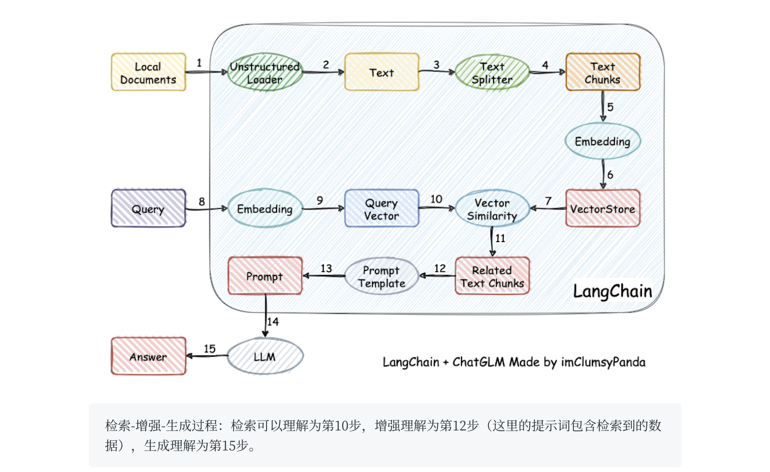

我们来走一遍这个流程：
1. 各类型文档通过不同类型的文档加载器Loader加载后进行分词
2. 分词之后会生成不同的Chunk
3. 将Chunk通过Embedding嵌入向量模型存入向量数据库

用户在查询时：
1. 将用户输入的提示词也通过Embedding嵌入向量模型计算向量值
2. 从向量数据库中查询和该提示词向量最相似的Top K个向量（余弦相似度）
3. 将相似向量上下文增强进提示词模版发送给大模型
4. 大模型返回检索增强后的消息返回给用户

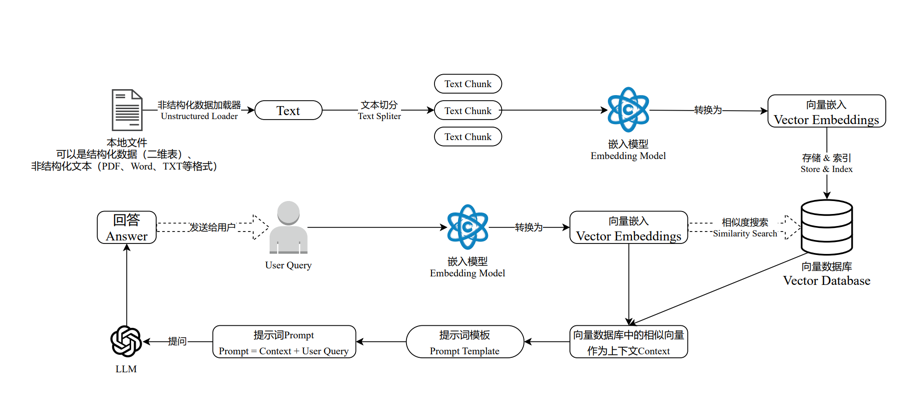

而这其中的难点主要存在于：

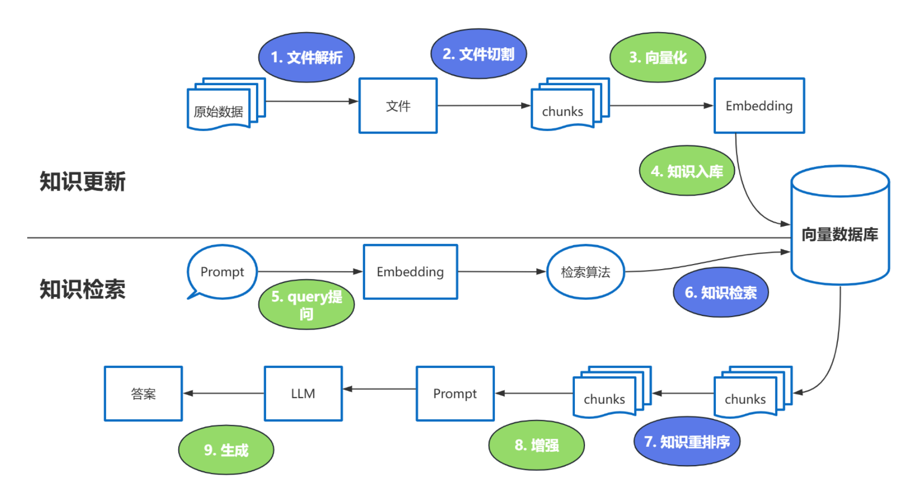

- 文件解析
- 文件切割
- 知识检索
- 知识重排序

## 大模型开发-基于Agent架构的开发

基于Agent结构开发大模型应用的关键在于如何充分利用AI大模型的推理和决策能力，通过增加规划、记忆和工具的能力，构建一个类似人类能够独立思考、逐步完成给定目标的智能体。

下面是一个经典的AI Agent架构图，主要表示一个完整的AI Agent由下面5部分组成

- LLM 大语言模型 提供决策中枢和推理能力
- Memory 提供上下文记忆
  - 短期记忆 存储当前对话的上下文信息 受限于模型的上下文窗口长度
  - 长期记忆 可以跨多周期、多窗口存储知识，主要实现方式有：
    - 模型参数微调 固化知识
    - 知识图谱 结构化语义网络
    - 向量数据库 相似度检索
- Tools 提供调用工具和第三方API能力
- Planning 提供规划能力
  - 通过分解任务、反思和自我批评等手段
  - 通过思维链将目标拆分为子任务，并通过用户反馈优化策略
- Action 实际执行决策模块 比如软件接口操作订票下单或者物理交互如机器人执行搬运

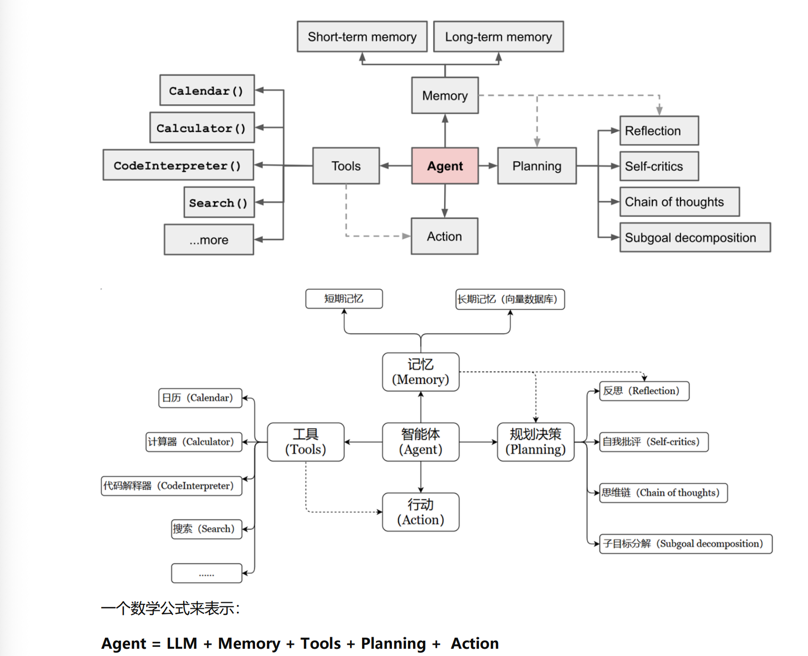


## LangChain核心组件

LangChain核心组件涉及以下几个不同的模块：
1. Model I/O 标准化不同大模型输入和输出及接口调用
2. Chains 将多个模块串联起来组成完整流程
3. Memory 记忆模块
4. Agents 智能体
5. Retrieval 检索增强生成
6. Callbacks 监控分析LangChain运行

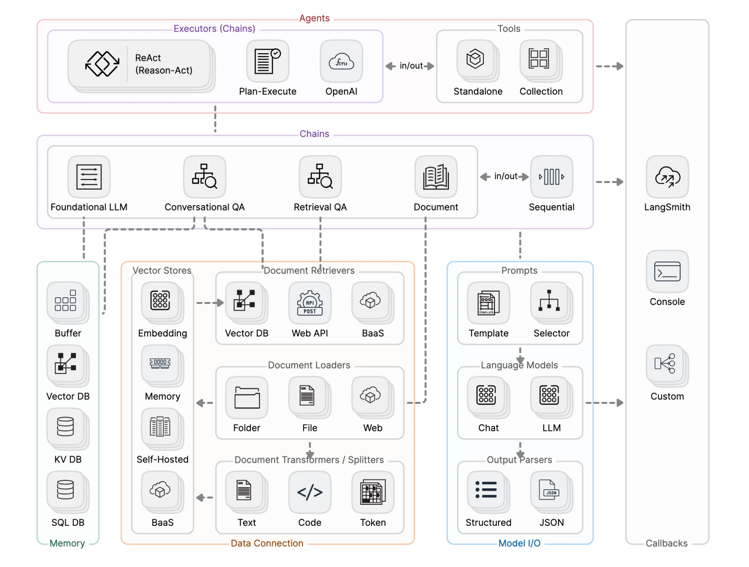

In [4]:
# 简单调用LangChain
import dotenv;
import os;
from langchain_openai import ChatOpenAI;

dotenv.load_dotenv();

OPENAI_API_KEY= os.getenv('OPENAI_API_KEY');
MODEL_NAME = os.getenv('MODEL_NAME')
BASE_URL = os.getenv('BASE_URL')


model = ChatOpenAI(model=os.environ['MODEL_NAME'],base_url=os.environ['BASE_URL'],api_key=os.environ['OPENAI_API_KEY']);
response = model.invoke('请你介绍一下自己')
print(response.content)

你好！我是通义千问，是阿里巴巴集团旗下的通义实验室自主研发的超大规模语言模型。我能够回答问题、创作文字，比如写故事、写公文、写邮件、写剧本、逻辑推理、编程等等，还能表达观点，玩游戏等。如果你有任何问题或需要帮助，欢迎随时告诉我，我会尽力提供支持！
